In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Path to the dataset (adjust if different)
source_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT"

# Check if directory exists
if os.path.exists(source_dir):
    print("✅ Dataset found at:", source_dir)
else:
    print("❌ Dataset not found. Please check the path.")


✅ Dataset found at: /content/drive/MyDrive/project/basepaper/EuroSAT


In [ ]:
import os
import shutil
import random
from tqdm import tqdm

# Updated dataset path
original_data_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT"
base_split_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT_full_split"
split_ratio = (0.7, 0.15, 0.15)  # Train, Val, Test
split_dirs = ['train', 'val', 'test']

# Create split directories if not exist
for split in split_dirs:
    os.makedirs(os.path.join(base_split_dir, split), exist_ok=True)

# Check if already split
already_split = all(
    os.path.exists(os.path.join(base_split_dir, split, class_name))
    for split in split_dirs
    for class_name in os.listdir(original_data_dir)
    if os.path.isdir(os.path.join(original_data_dir, class_name))
)

if not already_split:
    print("📂 Splitting full dataset into train, val, and test folders...")

    class_names = os.listdir(original_data_dir)
    for class_name in tqdm(class_names, desc="Splitting"):
        class_dir = os.path.join(original_data_dir, class_name)
        if not os.path.isdir(class_dir):
            continue

        images = sorted(os.listdir(class_dir))
        images = [img for img in images if img.lower().endswith((".jpg", ".jpeg", ".png"))]
        random.shuffle(images)

        n_total = len(images)
        n_train = int(n_total * split_ratio[0])
        n_val = int(n_total * split_ratio[1])

        split_paths = {
            'train': images[:n_train],
            'val': images[n_train:n_train + n_val],
            'test': images[n_train + n_val:]
        }

        for split in split_dirs:
            split_class_dir = os.path.join(base_split_dir, split, class_name)
            os.makedirs(split_class_dir, exist_ok=True)
            for img_name in split_paths[split]:
                src_path = os.path.join(class_dir, img_name)
                dst_path = os.path.join(split_class_dir, img_name)
                shutil.copy(src_path, dst_path)

    print("✅ Dataset split completed successfully.")
else:
    print("✅ Dataset already split. Skipping splitting.")


✅ Dataset already split. Skipping splitting.


Found 19006 files belonging to 10 classes.
Found 4070 files belonging to 10 classes.
Found 4077 files belonging to 10 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7750 - loss: 0.7679
Epoch 1: val_accuracy improved from -inf to 0.93857, saving model to /content/drive/MyDrive/project/basepaper/best_model_eurosat_b0.h5


594/594 ━━━━━━━━━━━━━━━━━━━━ 2764s 5s/step - accuracy: 0.7751 - loss: 0.7674 - val_accuracy: 0.9386 - val_loss: 0.2073
Epoch 2/3
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9279 - loss: 0.2337
Epoch 2: val_accuracy improved from 0.93857 to 0.94963, saving model to /content/drive/MyDrive/project/basepaper/best_model_eurosat_b0.h5


594/594 ━━━━━━━━━━━━━━━━━━━━ 1824s 3s/step - accuracy: 0.9279 - loss: 0.2337 - val_accuracy: 0.9496 - val_loss: 0.1625
Epoch 3/3
594/594 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9361 - loss: 0.1974
Epoch 3: val_accuracy improved from 0.94963 to 0.95455, saving model to /content/drive/MyDrive/project/basepaper/best_model_eurosat_b0.h5


594/594 ━━━━━━━━━━━━━━━━━━━━ 1801s 3s/step - accuracy: 0.9361 - loss: 0.1974 - val_accuracy: 0.9545 - val_loss: 0.1463
128/128 ━━━━━━━━━━━━━━━━━━━━ 539s 4s/step - accuracy: 0.9507 - loss: 0.1465

✅ Test Accuracy: 95.02%


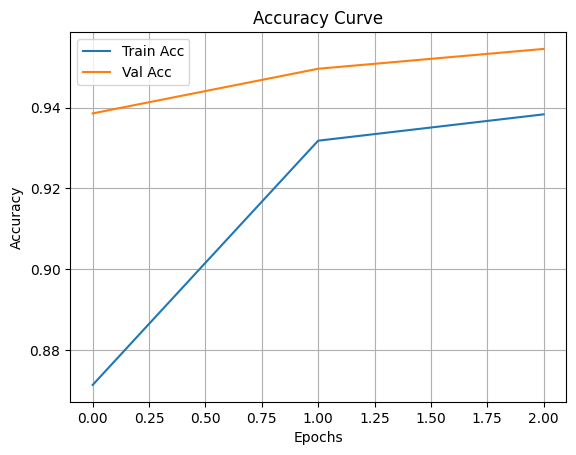

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

# Parameters
img_size = (224, 224)
batch_size = 32
num_classes = 10
base_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT_full_split"
epochs = 3  # ✅ Reduced from 30 to 10

# Load datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(base_dir, "train"),
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(base_dir, "val"),
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(base_dir, "test"),
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical'
)

# Prefetch
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# Model setup
base_model = EfficientNetB0(include_top=False, input_shape=img_size + (3,), weights='imagenet')
base_model.trainable = False  # Frozen for feature extraction

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
predictions = Dense(num_classes, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=predictions)

# Compile
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks
checkpoint_path = "/content/drive/MyDrive/project/basepaper/best_model_eurosat_b0.h5"
callbacks = [
    ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)
]

# Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks
)

# Evaluate
test_loss, test_acc = model.evaluate(test_ds)
print(f"\n✅ Test Accuracy: {test_acc * 100:.2f}%")

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.grid(True)
plt.show()
